In [2]:
# paths
import numpy as np
import pandas as pd
from scipy import stats
import sys

sys.path.append('helpers/')
from dual_pfc_funcs import getParams, load_dict, prinangle
import helpers.pcca_fa.pcca_fa_mdl as pf

import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from matplotlib.backends.backend_pdf import PdfPages
plt.style.use('scifigs.mplstyle')
SAVE_FIG = False

# parameters
params = getParams()
subjects = params['subjects']
color_map = params['color_map']
thetas = [30,60,90]

In [3]:
data_path = 'preprocessed_data/'
dat = load_dict(data_path + 'simdataset_varyThetaShuffle.pkl')
cols = ['SessionName'] + list(list(dat.values())[0].keys())
df = pd.DataFrame(columns=cols)
for i, (sess, curr_dat) in enumerate(dat.items()):    
    df2 = {'SessionName':sess,**curr_dat}
    df.loc[len(df)] = df2
# df

Example session angle: 63.40


/var/folders/n6/25pbyfj56mj_j3jqsv8rcw480000gn/T/ipykernel_64720/4282304748.py:46: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/var/folders/n6/25pbyfj56mj_j3jqsv8rcw480000gn/T/ipykernel_64720/4282304748.py:53: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


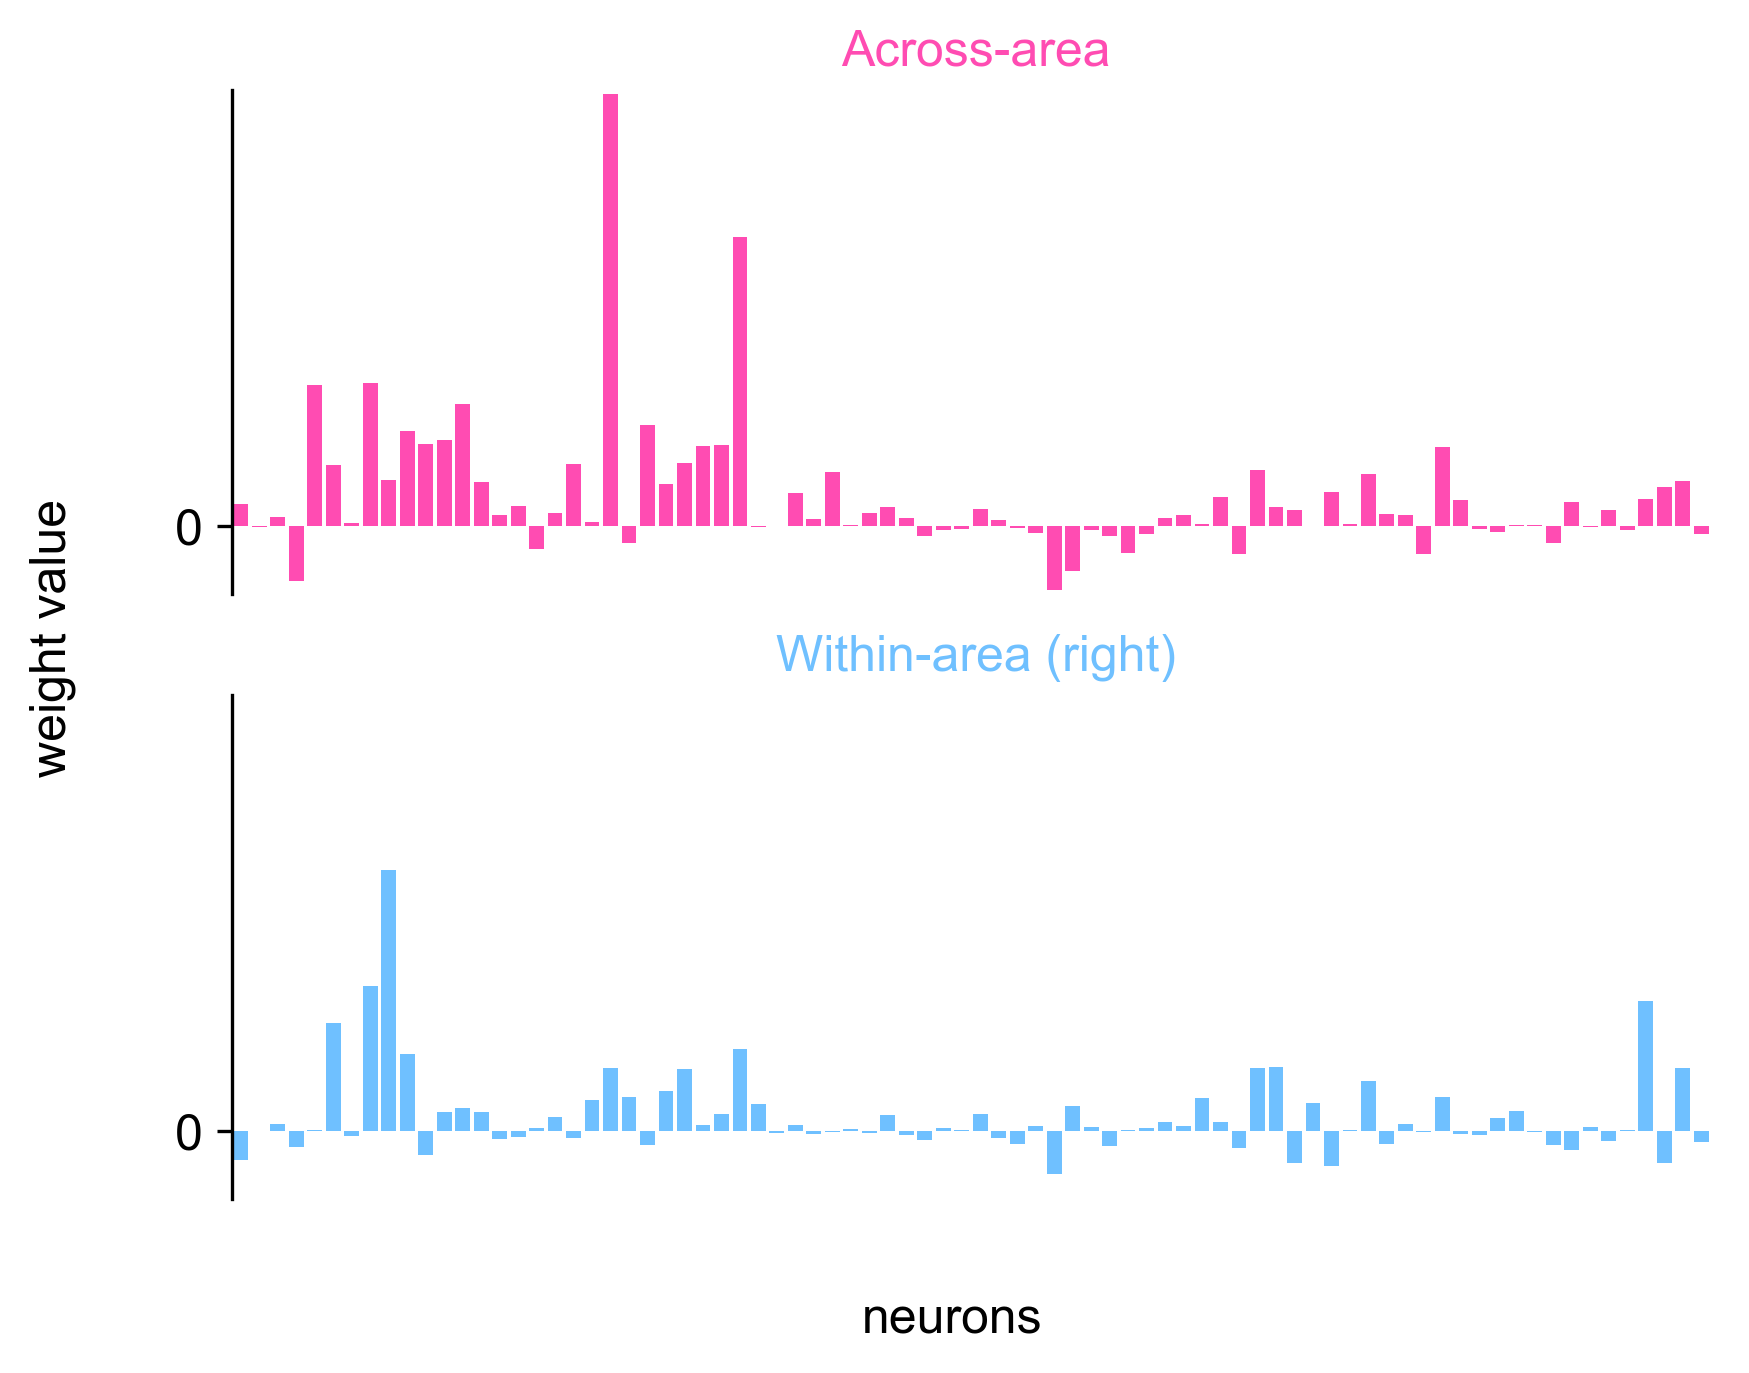

In [4]:
# example session weights:
pccafa = load_dict(data_path + 'pepe_pccafa_cv15dim.pkl')
sess = 'Pe180718'
ex_params = pccafa[sess]['params']
Ny = ex_params['W_y'].shape[0]

mdl = pf.pcca_fa()
mdl.set_params(ex_params)
_,top_wy,_,top_ly, = mdl.orthogonalize(across_mode='unpaired') # orthogonalize all latents!
top_wy = top_wy[:,0]
top_ly = top_ly[:,0]

# flip vecs if needed
if ((top_wy >= 0).sum() / Ny) < 0.5: top_wy = -top_wy
if ((top_ly >= 0).sum() / Ny) < 0.5: top_ly = -top_ly

ex_sess_angle = prinangle(top_wy, top_ly)[0]
print('Example session angle: {:.2f}'.format(ex_sess_angle))

max_y = np.amax(np.concatenate((top_wy,top_ly)))
min_y = np.amin(np.concatenate((top_wy,top_ly)))
xdata = np.arange(Ny)

# plot weights from top L and top W from right hem
fig, axs = plt.subplots(2,1, constrained_layout=False,sharey=True,sharex=True)

axs[0].bar(xdata, top_wy, color=color_map['across'])
axs[1].bar(xdata, top_ly, color=color_map['within1'])

axs[0].set_title('Across-area', fontsize=12, color=color_map['across'])
axs[0].set_xlim([-0.5,Ny])
axs[0].set_ylim([min_y-0.1,max_y+0.1])
axs[0].set_xticks([])
axs[0].set_yticks([0])
axs[0].spines['bottom'].set_visible(False)

axs[1].set_title('Within-area (right)', fontsize=12, color=color_map['within1'])
axs[1].set_xlim([-0.5,Ny])
axs[1].set_ylim([min_y-0.1,max_y+0.1])
axs[1].set_xticks([])
axs[1].set_yticks([0])
axs[1].spines['bottom'].set_visible(False)

fig.supylabel('weight value', fontsize=12)
fig.supxlabel('neurons', fontsize=12)
fig.show()

if SAVE_FIG:
    pdf = PdfPages('figs/weights_ex_sess.pdf')
    pdf.savefig(fig)
    pdf.close()
else:
    fig.show()

Average neural angle: 68.19 deg


/var/folders/n6/25pbyfj56mj_j3jqsv8rcw480000gn/T/ipykernel_64720/4062729131.py:26: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


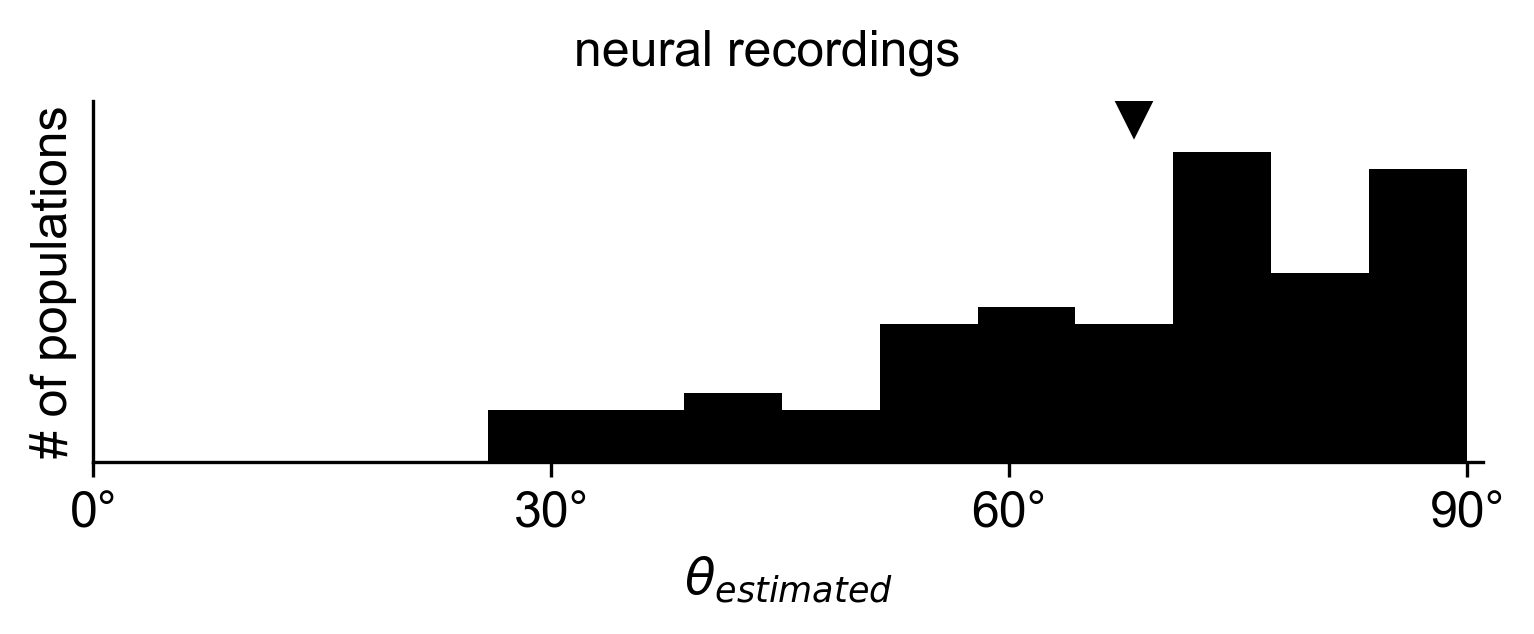

In [14]:
bins = np.arange(0,95,4)

fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(5,2))
fig.suptitle('neural recordings')

# real data
ylim = 20
real_data = np.concatenate((df['neural_x'],df['neural_y']))
ax.hist(real_data, color='k')
ax.plot(real_data.mean(),ylim,color='k',marker='v',markersize=8)
print('Average neural angle: {:.2f} deg'.format(np.mean(real_data)))

ax.set_xlim([0,91])
ax.set_xticks(np.arange(0,91,30))
ax.set_yticks([])
ax.set_ylabel('# of populations')
ax.set_xlabel(r'$\theta_{estimated}$')
ax.xaxis.set_major_formatter(StrMethodFormatter(u"{x:.0f}°"))


if SAVE_FIG:
    pdf = PdfPages('figs/angles_neural.pdf')
    pdf.savefig(fig)
    pdf.close()
else:
    fig.show()

/var/folders/n6/25pbyfj56mj_j3jqsv8rcw480000gn/T/ipykernel_64720/1084380745.py:37: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


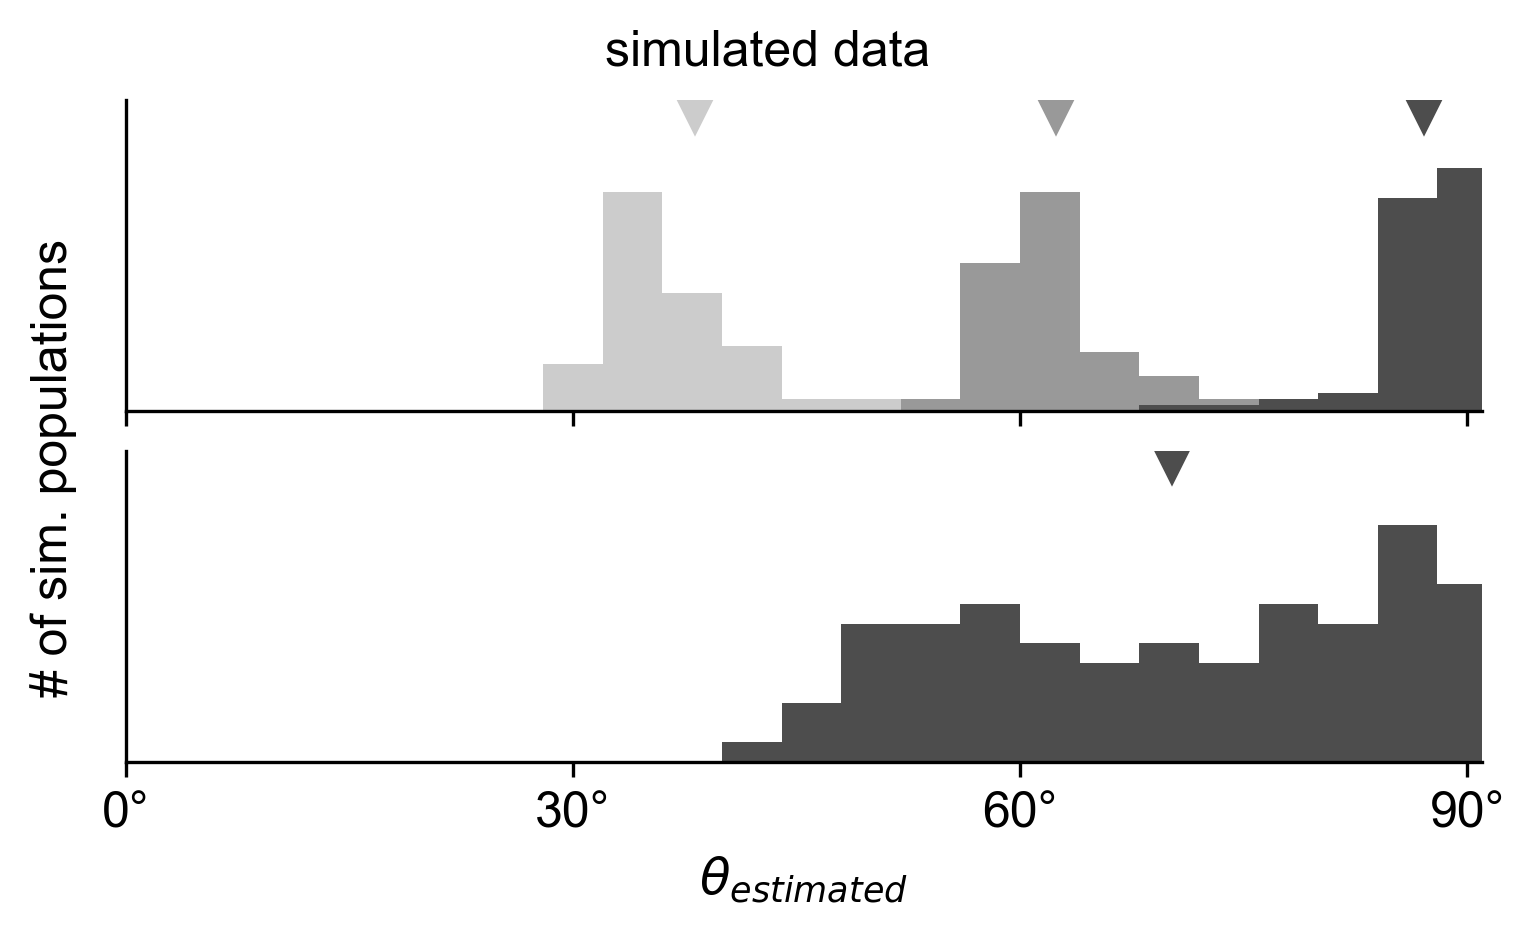

In [15]:
colors = ['0.8','0.6','0.3']
bins = np.arange(0,95,4)

fig, ax = plt.subplots(2, 1, constrained_layout=True,sharex=True, figsize=(5,3))
fig.suptitle('simulated data')
fig.supylabel('# of sim. populations', fontsize=12)

# structured alignment
ylim = 50
for k,theta in enumerate(thetas,1):
    xdata = np.concatenate((df['fit_theta{}_x'.format(theta)],df['fit_theta{}_y'.format(theta)]))
    ax[0].hist(x=xdata, color=colors[k-1], label=str(theta)+"deg", bins=bins)
    ax[0].plot(xdata.mean(),ylim,color=colors[k-1],marker='v',markersize=8)

# random alignment
ylim = 15
xdata = np.concatenate((df['fit_rand_x'],df['fit_rand_y']))
ax[1].hist(x=xdata, color=colors[-1], label="45-90deg", bins=bins)
ax[1].plot(xdata.mean(),ylim,color=colors[k-1],marker='v',markersize=8)

ax[0].set_xlim([0,91])
ax[0].set_xticks(np.arange(0,91,30))
ax[0].set_yticks([])
ax[0].xaxis.set_major_formatter(StrMethodFormatter(u"{x:.0f}°"))

ax[1].set_xlim([0,91])
ax[1].set_xticks(np.arange(0,91,30))
ax[1].set_yticks([])
ax[1].set_xlabel(r'$\theta_{estimated}$')
ax[1].xaxis.set_major_formatter(StrMethodFormatter(u"{x:.0f}°"))

if SAVE_FIG:
    pdf = PdfPages('figs/angles_sim.pdf')
    pdf.savefig(fig)
    pdf.close()
else:
    fig.show()

In [7]:
# panel d statistics:
# t test to compare the difference in means between real data and aligned dists. 
# one-sided: is real data greater than chance?
alpha = 0.01

for k,theta in enumerate(thetas,1):
    simdata = np.concatenate((df['fit_theta{}_x'.format(theta)],df['fit_theta{}_y'.format(theta)]))
    p = stats.ttest_rel(real_data, simdata, alternative='greater').pvalue
    print("Real data greater than {} deg? {}, p={:.5f}".format(theta, p<alpha, p))

Real data greater than 30 deg? True, p=0.00000
Real data greater than 60 deg? True, p=0.00092
Real data greater than 90 deg? False, p=1.00000
